<a href="https://colab.research.google.com/github/Arhammanj/Arhammanj/blob/main/EDAproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving daraz_dataset7.csv to daraz_dataset7 (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv('dataset2.csv')
print(df.isnull().sum())

Product Name                 0
Current Price                0
Original Price             710
Discount                   710
Rating Stars               710
Reviews Count              710
Sold Units                 422
Product URL                  0
Original Price (detail)    710
Discount Percent           710
Average Rating             636
Product Description        669
Specifications             710
Brand                        4
Model                      701
Delivery Time              710
Return Policy              710
Warranty                   693
dtype: int64


In [ ]:
print(df.dtypes)


Product Name                object
Current Price               object
Original Price             float64
Discount                   float64
Rating Stars               float64
Reviews Count              float64
Sold Units                  object
Product URL                 object
Original Price (detail)    float64
Discount Percent           float64
Average Rating             float64
Product Description         object
Specifications             float64
Brand                       object
Model                       object
Delivery Time              float64
Return Policy              float64
Warranty                    object
dtype: object


In [ ]:
df['Current Price'] = df['Current Price'].replace('[$,Rs. ]', '', regex=True).astype(float)
df['Original Price'] = df['Original Price'].replace('[$,Rs. ]', '', regex=True).astype(float)

In [ ]:
df.drop_duplicates(subset=['Product URL'], inplace=True)


In [ ]:
df['Product Name'] = df['Product Name'].str.strip()


After uploading, the file will be available in the current working directory of your Colab session. You can then modify the `pd.read_csv` line to use the correct filename.

In [ ]:
df.describe()


,Current Price,Original Price,Discount,Rating Stars,Reviews Count,Original Price (detail),Discount Percent,Average Rating,Specifications,Delivery Time,Return Policy
count,710.000000,0.0,0.0,0.0,0.0,0.0,0.0,74.0,0.0,0.0,0.0
mean,61942.280282,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
std,100811.864715,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
min,99.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
25%,6999.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
50%,31379.500000,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
75%,69749.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
max,977299.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


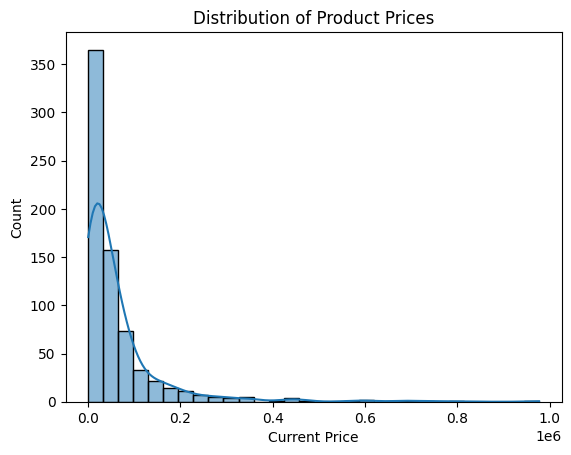

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Current Price'], bins=30, kde=True)
plt.title("Distribution of Product Prices")
plt.show()


In [ ]:
top_rated = df.sort_values(by='Average Rating', ascending=False).head(10)
print(top_rated[['Product Name', 'Average Rating', 'Current Price']])

                                          Product Name  Average Rating  \
1    Apple iPhone 15 Pro 128GB - Non Approved - Fac...             0.0   
10   Apple iPhone 17 Pro Max _ 6.9" Inch Display _ ...             0.0   
38   Tecno spark 40 II 6Gb Ram 128Gb Rom II 5200mAh...             0.0   
53   Google pixel 6 Pro |. 12 GB RAM 128 GB & 256 G...             0.0   
66           Samsung Galaxy A07 6GB+128GB PTA APPROVED             0.0   
75   Tecno Spark 40C II 4Gb Ram 128gb Rom II 6000mA...             0.0   
89   TCL 30z - 6.08 Inches Display - 3GB RAM + 32GB...             0.0   
100  Vivo Y71 | 3GB Ram | 32GB Rom | Used but Like ...             0.0   
108  Imported Oppo Reno Z2 with Box Vooc Charger Ha...             0.0   
143  Moto G Pure - 6.5 Inches HD+ Display - 3GB RAM...             0.0   

     Current Price  
1         199999.0  
10        977299.0  
38         37499.0  
53         74018.0  
66         36135.0  
75         30499.0  
89          8499.0  
100         8999.

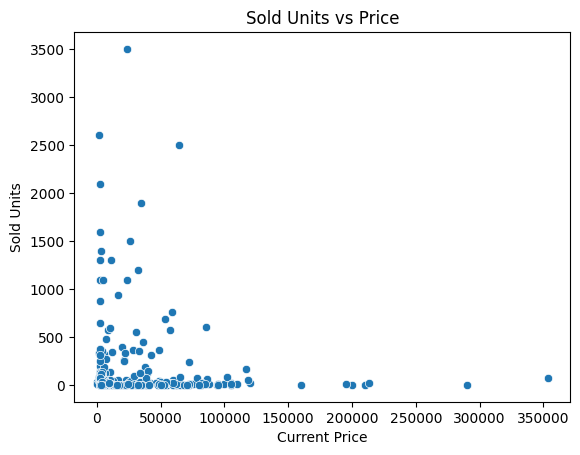

In [ ]:
def clean_sold_units(value):
    if pd.isna(value):
        return None
    s_value = str(value).strip().lower()
    multiplier = 1.0

    if 'k' in s_value:
        s_value = s_value.replace('k', '')
        multiplier = 1000.0

    if 'sold' in s_value:
        s_value = s_value.replace('sold', '').strip()

    try:
        return float(s_value) * multiplier
    except ValueError:
        return None

df['Sold Units'] = df['Sold Units'].apply(clean_sold_units)
sns.scatterplot(x='Current Price', y='Sold Units', data=df)
plt.title("Sold Units vs Price")
plt.show()

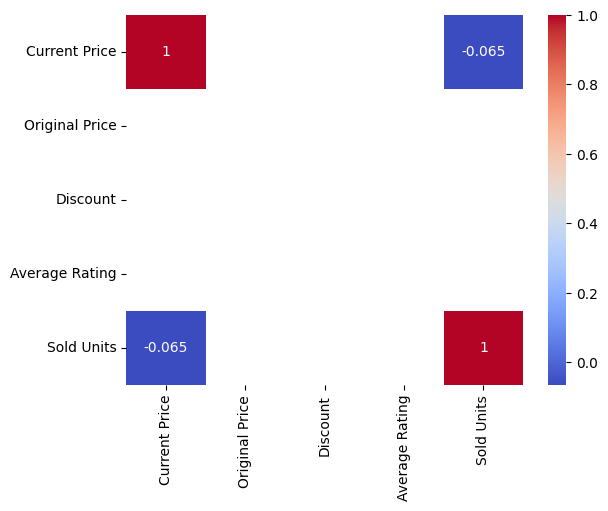

In [ ]:
corr = df[['Current Price', 'Original Price', 'Discount', 'Average Rating', 'Sold Units']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
from scipy.stats import zscore

df['z_score'] = zscore(df['Current Price'])
outliers = df[df['z_score'].abs() > 3]


In [ ]:
Q1 = df['Current Price'].quantile(0.25)
Q3 = df['Current Price'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Current Price'] < Q1 - 1.5*IQR) | (df['Current Price'] > Q3 + 1.5*IQR)]


In [ ]:
df['Price Category'] = pd.cut(df['Current Price'], bins=[0, 15000, 30000, 50000, 100000], labels=['Low', 'Mid', 'High', 'Premium'])


In [ ]:
df['Has Discount'] = df['Discount'].apply(lambda x: 1 if x > 0 else 0)


In [ ]:
df['Rating Category'] = pd.cut(df['Average Rating'], bins=[0, 2, 3.5, 4.5, 5], labels=['Poor', 'Average', 'Good', 'Excellent'])

In [ ]:
top_brands = df['Brand'].value_counts().head(5)

In [ ]:
avg_price = df.groupby('Brand')['Current Price'].mean().sort_values(ascending=False)


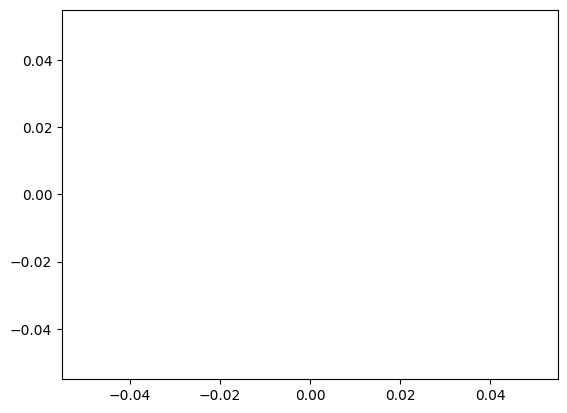

In [ ]:
sns.scatterplot(x='Discount', y='Sold Units', data=df)
plt.show()


In [ ]:
df.to_csv("cleaned_mobile_products.csv", index=False)


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Example features
features = ['Current Price', 'Average Rating'] # Removed 'Discount' due to all null values
target = 'Sold Units'

# Drop rows with missing target or features
df_ml = df.dropna(subset=features + [target])

X = df_ml[features]
y = df_ml[target]

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results:")
print(f"MSE: {mse:.2f}")
print(f"R2 Score: {r2:.2f}")

# Example prediction
example = pd.DataFrame({'Current Price':[90000], 'Average Rating':[4.5]})
pred_sold_units = model.predict(example)
print(f"Predicted Sold Units: {int(pred_sold_units[0])}")

Linear Regression Results:
MSE: 7418.65
R2 Score: -3.22
Predicted Sold Units: 42


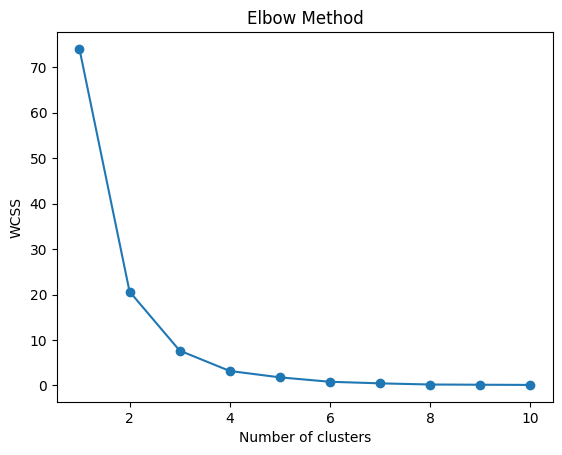

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# Features for clustering
cluster_features = df[['Current Price', 'Average Rating']].dropna()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_features)

# Use Elbow method to find optimal k
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot elbow curve
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

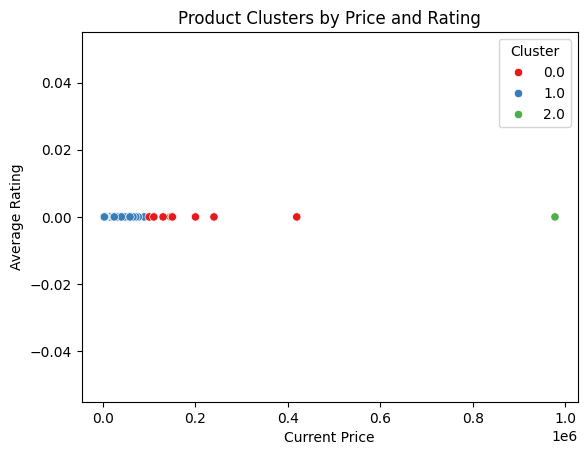

In [ ]:
# Fit KMeans with chosen k
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)

# Assign clusters back to the original DataFrame using the index of clustered features
df['Cluster'] = pd.Series(cluster_labels, index=cluster_features.index)

# Visualize clusters
sns.scatterplot(x='Current Price', y='Average Rating', hue='Cluster', data=df, palette='Set1')
plt.title("Product Clusters by Price and Rating")
plt.show()

Dataset saved to: mobile_products_clustered.csv
